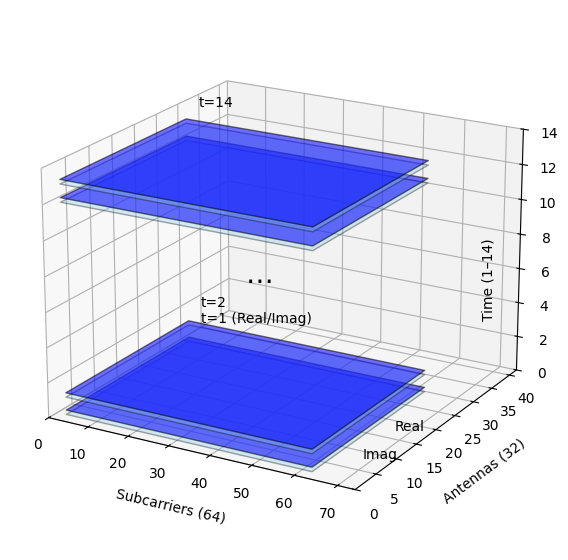

In [42]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt

# --- figure/axes ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

rows, cols = 32, 64
depths = [0, 1, 12, 13]   # 0->t=1, 13->t=14
dz = 0.25
MARGIN_X, MARGIN_Y = 2, 2

def add_slice(z, color=None, alpha=0.5):
    verts = [[(MARGIN_X, MARGIN_Y, z),
              (cols - MARGIN_X, MARGIN_Y, z),
              (cols - MARGIN_X, rows - MARGIN_Y, z),
              (MARGIN_X, rows - MARGIN_Y, z)]]
    poly = Poly3DCollection(verts, linewidths=1, alpha=alpha, facecolors=color)
    poly.set_edgecolor('k')
    ax.add_collection3d(poly)

# draw Real/Imag layers
for d in depths:
    add_slice(d,     color="skyblue", alpha=0.35)  # Imag
    add_slice(d+dz,  color="blue",    alpha=0.55)  # Real

# labels inside the volume
ax.text(0, rows+3, 0+dz, "t=1 (Real/Imag)")
ax.text(0, rows+3, 1+dz, "t=2")
ax.text(cols/2, rows/2, 6.5, "⋯", fontsize=20)
ax.text(0, rows+3, 13+dz, "t=14")

# Real/Imag side labels
ax.text(cols+4, rows/2, depths[0]+dz, "Real")
ax.text(cols+4, rows/4, depths[0],    "Imag")

# axis labels
ax.set_xlabel("Subcarriers (64)", labelpad=8)
ax.set_ylabel("Antennas (32)", labelpad=8)

# make z label vertical (parallel to axis)
ax.zaxis.set_rotate_label(True)
ax.set_zlabel("Time (1–14)", rotation=90, labelpad=10)

# axis limits and view
ax.set_xlim(0, cols+10)
ax.set_ylim(0, rows+10)
ax.set_zlim(0, 14)
ax.view_init(elev=20, azim=-60)
ax.text2D(0.90, 0.50, "Time (1–14)", transform=ax.transAxes,
          rotation=90, va='center', ha='right')

# adjust margins manually (no tight_layout)
fig.subplots_adjust(left=0.05, right=0.92, bottom=0.08, top=0.98)

plt.show()


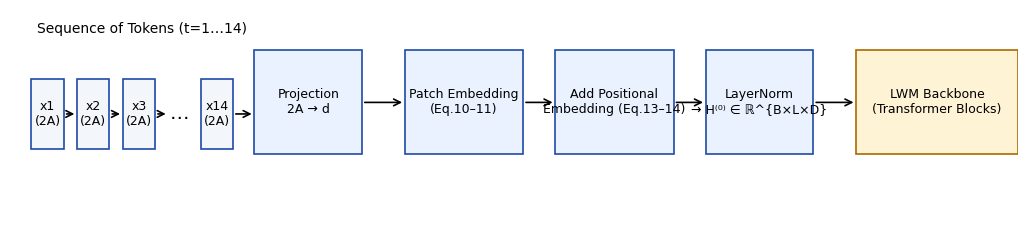

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

def box(ax, xy, w, h, text, fc="#eaf2ff", ec="#1f4aa8", fontsize=9, lw=1.2):
    r = Rectangle(xy, w, h, facecolor=fc, edgecolor=ec, lw=lw)
    ax.add_patch(r)
    ax.text(xy[0]+w/2, xy[1]+h/2, text, ha="center", va="center", fontsize=fontsize)

def arrow(ax, x0, y0, x1, y1, text=None, fontsize=9, mutation_scale=12):
    arr = FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="->",
                          mutation_scale=mutation_scale, lw=1.2, color="black")
    ax.add_patch(arr)
    if text:
        ax.text((x0+x1)/2, (y0+y1)/2 + 0.12, text, ha="center", va="bottom", fontsize=fontsize)

fig, ax = plt.subplots(figsize=(13, 3))
y = 1.0

# Input tokens
x = 0.4
for t in [1, 2, 3]:
    box(ax, (x, y), 0.6, 0.6, f"x{t}\n(2A)", fc="#f3f6fa")
    arrow(ax, x+0.6, y+0.3, x+0.85, y+0.3)
    x += 0.85
ax.text(x+0.2, y+0.3, "…", ha="center", va="center", fontsize=14)
x += 0.6
box(ax, (x, y), 0.6, 0.6, "x14\n(2A)", fc="#f3f6fa")
arrow(ax, x+0.6, y+0.3, x+1.0, y+0.3)

# Projection (2A→d)
proj_x = x+1.0
box(ax, (proj_x, y-0.05), 2.0, 0.9, "Projection\n2A → d")
arrow(ax, proj_x+2.0, y+0.4, proj_x+2.8, y+0.4)

# Patch Embedding
pe_x = proj_x+2.8
box(ax, (pe_x, y-0.05), 2.2, 0.9, "Patch Embedding\n(Eq.10–11)")
arrow(ax, pe_x+2.2, y+0.4, pe_x+2.8, y+0.4)

# Positional Embedding
pos_x = pe_x+2.8
box(ax, (pos_x, y-0.05), 2.2, 0.9, "Add Positional\nEmbedding (Eq.13–14)")
arrow(ax, pos_x+2.2, y+0.4, pos_x+2.8, y+0.4)

# LayerNorm → H^(0)
ln_x = pos_x+2.8
box(ax, (ln_x, y-0.05), 2.0, 0.9, "LayerNorm\n→ H⁽⁰⁾ ∈ ℝ^{B×L×D}")
arrow(ax, ln_x+2.0, y+0.4, ln_x+2.8, y+0.4)

# LWM Backbone
lwm_x = ln_x+2.8
box(ax, (lwm_x, y-0.05), 3.0, 0.9, "LWM Backbone\n(Transformer Blocks)", fc="#fff3d6", ec="#a86900")

ax.text(0.5, y+1.0, "Sequence of Tokens (t=1…14)", fontsize=10)

ax.set_xlim(0, lwm_x+3.0)
ax.set_ylim(0.2, 2.2)
ax.axis("off")
plt.show()
